In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [23]:
df = pd.read_csv("C:/Uner/Semester 4/Data Mining I/Week 4/fraudTrain.csv")
df_test = pd.read_csv("C:/Uner/Semester 4/Data Mining I/Week 4/fraudTest.csv")

In [24]:
df.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,...,37.9931,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
8,8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,...,40.3359,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [26]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [27]:
numerical_columns = df.select_dtypes(include=["int64", "float64"])
numerical_columns.head()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
0,0,2703186189652095,4.97,28654,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0
1,1,630423337322,107.23,99160,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0
2,2,38859492057661,220.11,83252,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0
3,3,3534093764340240,45.00,59632,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0
4,4,375534208663984,41.96,24433,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0


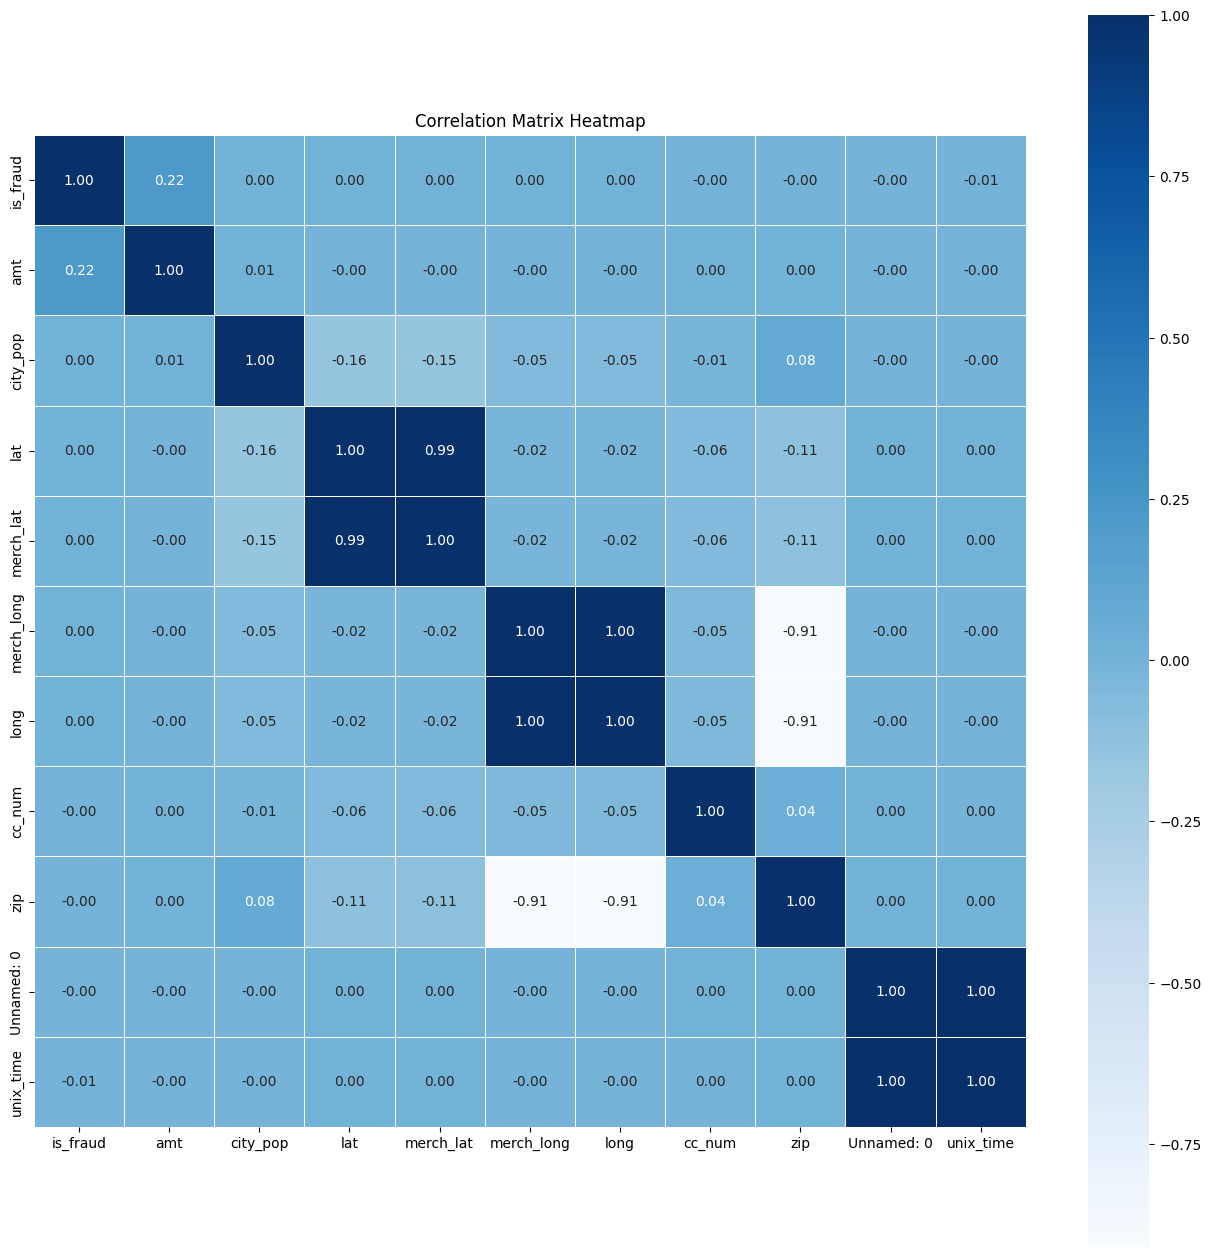

In [28]:
corr_matrix = numerical_columns.corr()

sorted_correlation = corr_matrix["is_fraud"].sort_values(ascending=False)

correlated_columns = sorted_correlation.index

subset_corr_matrix = corr_matrix.loc[correlated_columns, correlated_columns]

plt.figure(figsize=(16,16))

sns.heatmap(subset_corr_matrix, annot= True, cmap='Blues', linewidths=0.5, fmt=".2f", square= True)

plt.title("Correlation Matrix Heatmap")

plt.show()

In [29]:
x = df.drop(columns=['is_fraud'])
y = df['is_fraud']

In [30]:
x_num = numerical_columns.drop(columns=['is_fraud'])
y_num = numerical_columns['is_fraud']

In [31]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Fungsi SMOTE (Oversampling)
def smote(x, y, target_class, N=100, k=5):
    X_minority = x[y == target_class].values
    n_minority = len(X_minority)
    N = int((N / 100) * n_minority)
    
    print(f"Jumlah data minoritas sebelum SMOTE: {n_minority}")
    print(f"Jumlah data yang akan dihasilkan oleh SMOTE: {N}")
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_minority)
    synthetic_samples = []
    
    for _ in range(N):
        idx = np.random.randint(0, n_minority)
        sample = X_minority[idx]
        neighbors = nbrs.kneighbors([sample], return_distance=False)[0]
        neighbor_idx = np.random.choice(neighbors[1:])
        neighbor = X_minority[neighbor_idx]
        diff = neighbor - sample
        gap = np.random.rand()
        synthetic_sample = sample + gap * diff
        synthetic_samples.append(synthetic_sample)
    
    synthetic_samples = np.array(synthetic_samples)
    X_new = np.vstack((x.values, synthetic_samples))
    y_new = np.hstack((y.values, [target_class] * N))
    
    print(f"Jumlah data minoritas setelah SMOTE: {sum(y_new == target_class)}")
    
    return X_new, y_new

# Fungsi Undersampling
def undersample(x, y, majority_class, target_size):
    X_majority = x[y == majority_class].values
    y_majority = y[y == majority_class].values
    
    print(f"Jumlah data mayoritas sebelum undersampling: {len(X_majority)}")
    print(f"Jumlah data mayoritas setelah undersampling: {target_size}")
    
    indices = np.random.choice(len(X_majority), target_size, replace=False)
    X_majority_new = X_majority[indices]
    y_majority_new = y_majority[indices]
    
    return X_majority_new, y_majority_new

# Identifikasi kelas minoritas dan mayoritas
class_counts = y_num.value_counts()
target_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
print("Jumlah awal masing-masing kelas:")
print(class_counts)

# SMOTE Oversampling
X_oversampled, y_oversampled = smote(x_num, y_num, target_class, N=200, k=5)

# Undersampling Kelas Mayoritas
target_size = sum(y_oversampled == target_class)
X_undersampled, y_undersampled = undersample(pd.DataFrame(X_oversampled, columns=x_num.columns), 
                                              pd.Series(y_oversampled), majority_class, target_size)

# Gabungkan dataset setelah balancing
X_final = np.vstack((X_undersampled, X_oversampled[y_oversampled == target_class]))
y_final = np.hstack((y_undersampled, y_oversampled[y_oversampled == target_class]))

df_balanced = pd.DataFrame(X_final, columns=x_num.columns)
df_balanced['is_fraud'] = y_final

# Tampilkan jumlah data setelah balancing
print("Jumlah akhir masing-masing kelas setelah balancing:")
print(df_balanced['is_fraud'].value_counts())

# Simpan dataset hasil balancing
df_balanced.to_csv("C:/Uner/Semester 4/Data Mining I/Week 4/fraud_smote.csv", index=False)

print("✅ Kombinasi SMOTE + Undersampling selesai! Dataset baru telah disimpan.")


Jumlah awal masing-masing kelas:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Jumlah data minoritas sebelum SMOTE: 7506
Jumlah data yang akan dihasilkan oleh SMOTE: 15012
Jumlah data minoritas setelah SMOTE: 22518
Jumlah data mayoritas sebelum undersampling: 1289169
Jumlah data mayoritas setelah undersampling: 22518
Jumlah akhir masing-masing kelas setelah balancing:
is_fraud
0    22518
1    22518
Name: count, dtype: int64
✅ Kombinasi SMOTE + Undersampling selesai! Dataset baru telah disimpan.


#### Setelah di lakukan SMOTE, data minoritas ditingkatkan dengan ditambah 
#### sebanyak 200% dari data awalnya (karena rasio mayoritas/minoritas > 20).
#### Setelah itu data mayoritas di undersampling hingga sejumlah data minoritas
#### Sehingga rasio akhir data setelah di SMOTE menjadi 1:1
#### Untuk menguji kualitas data setelah di SMOTE saya membuat model machine learning menggunakan Xgboost & keras dengan hasil sebagai berikut:



===== Performa Model Sesudah Hybrid SMOTE =====
Accuracy: 0.9987
AUC-ROC: 0.9986
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     55356
           1       0.95      0.69      0.80       216

    accuracy                           1.00     55572
   macro avg       0.97      0.85      0.90     55572
weighted avg       1.00      1.00      1.00     55572



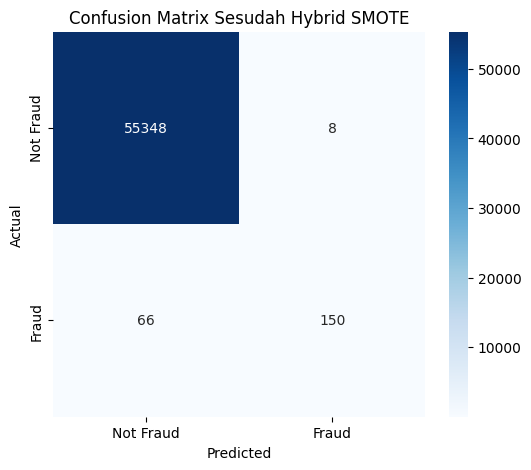

In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Pisahkan fitur dan target
X = df_test.drop(columns=['is_fraud'])
y = df_test['is_fraud']

# Encoding untuk fitur kategorikal
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Normalisasi fitur numerik
scaler = StandardScaler()
X[X.select_dtypes(include=['number']).columns] = scaler.fit_transform(
    X[X.select_dtypes(include=['number']).columns]
)

# Bagi dataset menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Buat model XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Latih model
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

print("\n===== Performa Model Sesudah Hybrid SMOTE =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')
print("Classification Report:\n", report)
plot_confusion_matrix(conf_matrix, "Confusion Matrix Sesudah Hybrid SMOTE")


# Keras

In [33]:
from sklearn.model_selection import train_test_split

Train_X, Test_X, Train_Y, Test_Y = train_test_split(x_num, y_num, test_size=0.2, random_state=42)

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

def build_model(input_shape):
  model = Sequential([
      Input(shape=(input_shape,)),
      Dense(64, activation='relu'),
      Dropout(0.5),
      Dense(32, activation='relu'),
      Dropout(0.5),
      Dense(1, activation='sigmoid')
  ])
  return model

input_shape = (Train_X.shape[1])
model = build_model(input_shape)


In [35]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    Train_X, Train_Y,
    batch_size=32,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1,
    validation_split=0.3
)

Epoch 1/100
22692/22692 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.9836 - loss: 351940324098048.0000 - val_accuracy: 0.9943 - val_loss: 0.0353
Epoch 2/100
22692/22692 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.9943 - loss: 224876953600.0000 - val_accuracy: 0.9943 - val_loss: 0.0353
Epoch 3/100
22692/22692 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - accuracy: 0.9941 - loss: 21571485696.0000 - val_accuracy: 0.9943 - val_loss: 0.0353
Epoch 4/100
22692/22692 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - accuracy: 0.9941 - loss: 40178184.0000 - val_accuracy: 0.9943 - val_loss: 0.0353


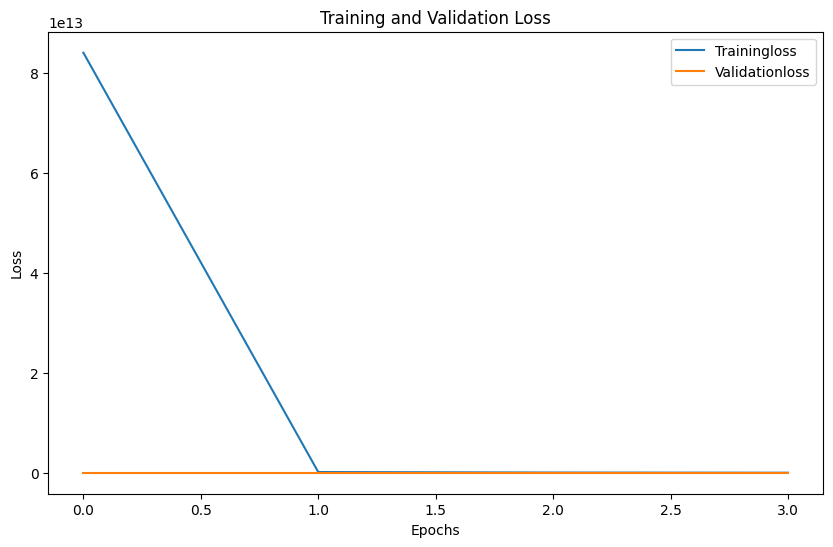

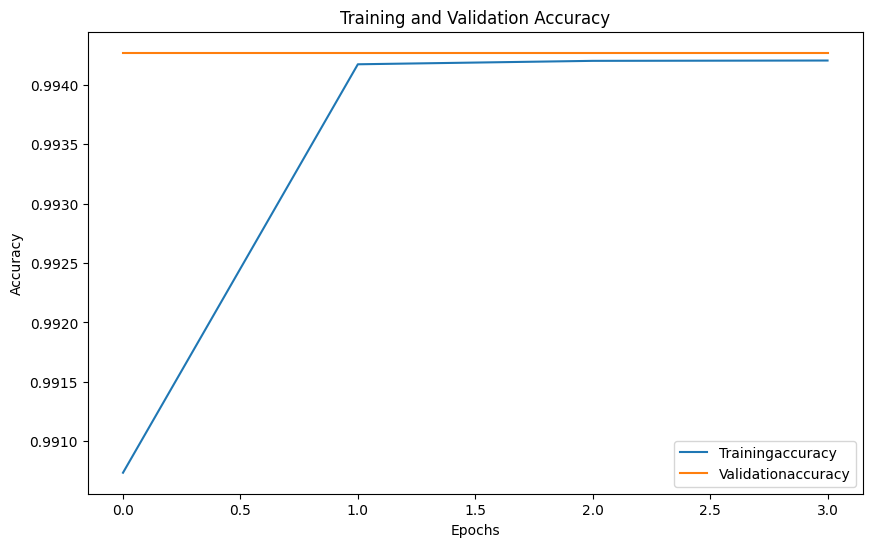

In [37]:
def plot_history(history, metric):
  plt.figure(figsize=(10, 6))
  plt.plot(history.history[metric], label = f'Training{metric}')
  plt.plot(history.history[f'val_{metric}'], label = f'Validation{metric}')
  plt.xlabel('Epochs')
  plt.ylabel(metric.capitalize())
  plt.title(f'Training and Validation {metric.capitalize()}')
  plt.legend()
  plt.show()

plot_history(history, 'loss')
plot_history(history, 'accuracy')

In [38]:
loss, accuracy = model.evaluate(Test_X, Test_Y)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

8105/8105 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9941 - loss: 0.0362
Test Loss: 0.0360
Test Accuracy: 0.9941


8105/8105 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


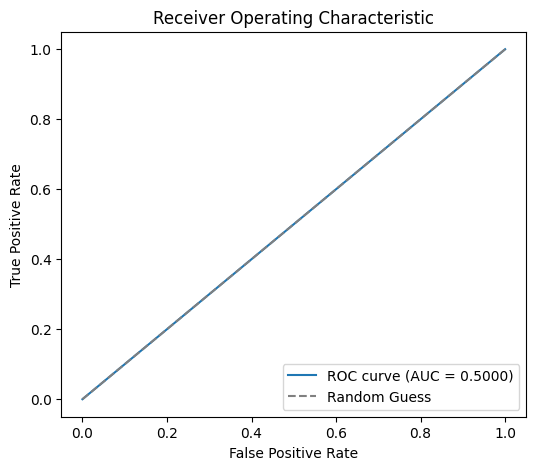

The roc_auc score for the ML model is 0.5


In [39]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict(Test_X)

fpr, tpr, thresholds = roc_curve(Test_Y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = "ROC curve (AUC = {:.4f})".format(roc_auc))
plt.plot([0,1], [0,1], linestyle = "--", color = "gray", label = "Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc = "lower right")
plt.show()
print("The roc_auc score for the ML model is {}".format(round(roc_auc, 4)))

In [40]:
df_new = pd.read_csv("C:/Uner/Semester 4/Data Mining I/Week 4/fraud_smote.csv")

In [41]:
df_new

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
0,7.445600e+05,4.658491e+15,120.630000,15449.0,39.9636,-79.7853,184.0,1.352924e+09,40.193240,-79.907147,0
1,1.048384e+06,3.559679e+15,115.660000,13367.0,43.7893,-75.4156,8830.0,1.362927e+09,43.700820,-75.151823,0
2,7.591170e+05,4.149238e+15,84.250000,15324.0,40.1008,-80.0652,632.0,1.353465e+09,40.950782,-80.081431,0
3,2.348970e+05,2.296007e+15,87.580000,11217.0,40.6816,-73.9798,2504700.0,1.335617e+09,40.750763,-74.087468,0
4,3.621520e+05,2.288814e+15,44.280000,10039.0,40.8265,-73.9383,1577385.0,1.339928e+09,40.894149,-74.085895,0
...,...,...,...,...,...,...,...,...,...,...,...
45031,1.636498e+05,3.759045e+14,904.060143,68973.0,40.4591,-98.5551,463.0,1.332889e+09,40.762055,-98.006349,1
45032,5.985694e+05,5.104807e+15,129.942931,11978.0,40.8295,-72.6473,3255.0,1.347330e+09,41.510971,-72.548036,1
45033,1.145494e+06,3.483795e+14,1080.806441,32935.0,28.1384,-80.6524,139650.0,1.366586e+09,27.832342,-81.173572,1
45034,1.065611e+06,3.565414e+15,907.836121,47869.0,39.4336,-87.4101,137.0,1.363559e+09,39.987477,-86.750420,1


In [42]:
df_new['is_fraud'].value_counts()

is_fraud
0    22518
1    22518
Name: count, dtype: int64